<div style="background:linear-gradient(135deg,#1a237e,#283593,#1565c0);
padding:36px 28px;border-radius:14px;color:#fff;text-align:center">
<h1 style="margin:0;font-size:2.1em">🏭 Caso Industrial 1 — Sector Petroquímico</h1>
<h2 style="margin:10px 0 4px;font-weight:300;opacity:.94">
Deshidrogenación Catalítica de Etilbenceno a Estireno</h2>
<p style="margin:6px 0 0;opacity:.85">
Reactores Batch · CSTR · PFR — Diseño Comparativo</p>
<p style="margin:4px 0 0;opacity:.75;font-size:.88em;font-style:italic">
740484 Diseño de Reactores · Universidad del Valle · Prof. José Antonio Lara Ramos</p>
</div>

---

## Contexto industrial

El **monómero de estireno** (C₆H₅CH=CH₂) es uno de los 20 químicos más producidos en el mundo
(~30 Mt/año). Es la materia prima de:

| Polímero | Aplicación |
|----------|-----------|
| Poliestireno (PS) | Empaques, vasos desechables, aislantes |
| ABS (Acrilonitrilo-Butadieno-Estireno) | Autopartes, electrónicos, tuberías |
| Caucho SBR (Estireno-Butadieno) | Neumáticos, suelas de zapatos |
| Resinas de poliéster insaturado | Fibra de vidrio, construcción naval |
| Látex estireno-butadieno | Pinturas, adhesivos, papel |

**Proceso industrial dominante:** deshidrogenación catalítica de etilbenceno (EB)
sobre catalizador Fe₂O₃/K₂O/Cr₂O₃ a 550–650°C, con inyección de vapor de agua
como diluyente (reduce la presión parcial de EB y desplaza el equilibrio).

---

## La reacción principal

$$\underbrace{C_6H_5CH_2CH_3}_{\text{etilbenceno (EB, A)}} \;\rightleftharpoons\;
\underbrace{C_6H_5CH=CH_2}_{\text{estireno (S, B)}} + H_2$$

- **Endotérmica**: $\Delta H_{rxn}^\circ = +117\;\text{kJ/mol}$ (requiere calor externo)
- **Reversible**: el equilibrio limita la conversión máxima
- **Incrementa moles gaseosos**: el vapor diluye EB y desplaza el equilibrio a la derecha

### Datos cinéticos (modelo simplificado — Fogler §10.3)

$$-r_{EB} = k_f C_{EB} - k_r C_S C_{H_2}$$

con:
$$k_f = 0.030\;\text{min}^{-1} \quad k_r = 0.015\;\text{dm}^3/(\text{mol}\cdot\text{min}) \quad
K_{eq} = k_f/k_r = 2.0\;\text{mol/dm}^3 \;\text{a } 600°\text{C}$$

### Condiciones de operación

| Variable | Valor | Unidades |
|----------|-------|----------|
| Temperatura | 600 | °C = 873 K |
| Presión | 1.2 | bar |
| $C_{EB,0}$ | 0.50 | mol/dm³ |
| Caudal $v_0$ | 120 | dm³/min |
| $F_{EB,0} = C_{EB,0}\cdot v_0$ | 60 | mol/min |
| Conversión deseada | 0.45 | — |

> **Limitación de equilibrio:** La conversión de equilibrio para estas condiciones es
> $X_{eq} \approx 0.55$, por lo que el diseño apunta a $X = 0.45$ (81% del equilibrio).

---

## Objetivos del caso

1. Calcular el **tiempo de reacción** para el reactor **Batch** y diseñar la operación por lotes.
2. Calcular el **volumen** del reactor **CSTR** y analizar la viabilidad de la conversión deseada.
3. Calcular el **volumen** del reactor **PFR** y comparar con el CSTR.
4. **Comparar** los tres reactores gráficamente mediante el Diagrama de Levenspiel.
5. Determinar el **número de CSTRs en serie** necesarios para aproximarse al rendimiento del PFR.


In [1]:
# Instalaciones e importaciones
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from scipy.integrate import odeint, cumulative_trapezoid
from scipy.optimize import brentq
from ipywidgets import interact, FloatSlider, IntSlider
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,'axes.grid':True,
    'grid.alpha':0.28,'figure.dpi':110,'axes.titlesize':12,
    'lines.linewidth':2.3,'axes.titleweight':'bold',
})

# ============================================================
# PARAMETROS DEL CASO — Deshidrogenacion de Etilbenceno
# ============================================================
kf   = 0.030    # min^-1  (constante directa)
kr   = 0.015    # dm^3/(mol*min)  (constante inversa)
Keq  = kf/kr    # mol/dm^3  (constante de equilibrio)
CEB0 = 0.50     # mol/dm^3  (concentracion inicial EB)
v0   = 120.0    # dm^3/min  (caudal volumetrico)
FEB0 = CEB0*v0  # mol/min   (flujo molar de EB)
Xdes = 0.45     # conversion deseada

# Conversion de equilibrio (analitica para esta cinetica)
# En equilibrio: kf*CEB = kr*CS*CH2
# CEB = CEB0*(1-Xeq), CS=CH2 = CEB0*Xeq (reaccion 1:1:1)
# kf*CEB0*(1-Xeq) = kr*(CEB0*Xeq)^2
# Solucion numerica:
Xeq = brentq(lambda X: kf*CEB0*(1-X) - kr*(CEB0*X)**2, 0.01, 0.999)

print("=" * 58)
print("  DESHIDROGENACION DE ETILBENCENO A ESTIRENO")
print("=" * 58)
print(f"  kf         = {kf}   min^-1")
print(f"  kr         = {kr}   dm^3/(mol*min)")
print(f"  Keq = kf/kr= {Keq:.3f}  mol/dm^3")
print(f"  C_EB0      = {CEB0}  mol/dm^3")
print(f"  v0         = {v0}  dm^3/min")
print(f"  F_EB0      = {FEB0:.1f}  mol/min")
print(f"  X deseada  = {Xdes}")
print(f"  X equilibrio = {Xeq:.4f}  (limite termodinamico)")
print(f"  X_des/X_eq = {Xdes/Xeq*100:.1f}% del equilibrio")
print("=" * 58)


  DESHIDROGENACION DE ETILBENCENO A ESTIRENO
  kf         = 0.03   min^-1
  kr         = 0.015   dm^3/(mol*min)
  Keq = kf/kr= 2.000  mol/dm^3
  C_EB0      = 0.5  mol/dm^3
  v0         = 120.0  dm^3/min
  F_EB0      = 60.0  mol/min
  X deseada  = 0.45
  X equilibrio = 0.8284  (limite termodinamico)
  X_des/X_eq = 54.3% del equilibrio


---
## Paso 1 — Análisis cinético y Diagrama de Levenspiel

### Velocidad de reacción neta

La cinética reversible incorpora tanto la reacción directa como la inversa:

$$-r_{EB}(X) = k_f\,C_{EB} - k_r\,C_S\,C_{H_2}$$

Con tabla estequiométrica para reacción 1:1:1 (fase líquida o gas diluido):

$$C_{EB} = C_{EB,0}(1-X) \qquad C_S = C_{H_2} = C_{EB,0}\,X$$

Sustituyendo:

$$\boxed{-r_{EB}(X) = k_f\,C_{EB,0}(1-X) - k_r\,(C_{EB,0}\,X)^2}$$

### Conversión de equilibrio

En equilibrio ($-r_{EB} = 0$):

$$k_f\,C_{EB,0}(1-X_{eq}) = k_r\,(C_{EB,0}\,X_{eq})^2$$

Esta ecuación cuadrática en $X_{eq}$ se resuelve numéricamente con `scipy.optimize.brentq`.

### Impacto del equilibrio en el diseño

Observe que la velocidad de reacción **se anula** en $X = X_{eq}$, lo que significa que el
Diagrama de Levenspiel diverge ($C_{EB,0}/(-r_{EB}) \to \infty$) al acercarse al equilibrio.
Esto implica que cualquier reactor que intente superar $X_{eq}$ requeriría un volumen infinito.


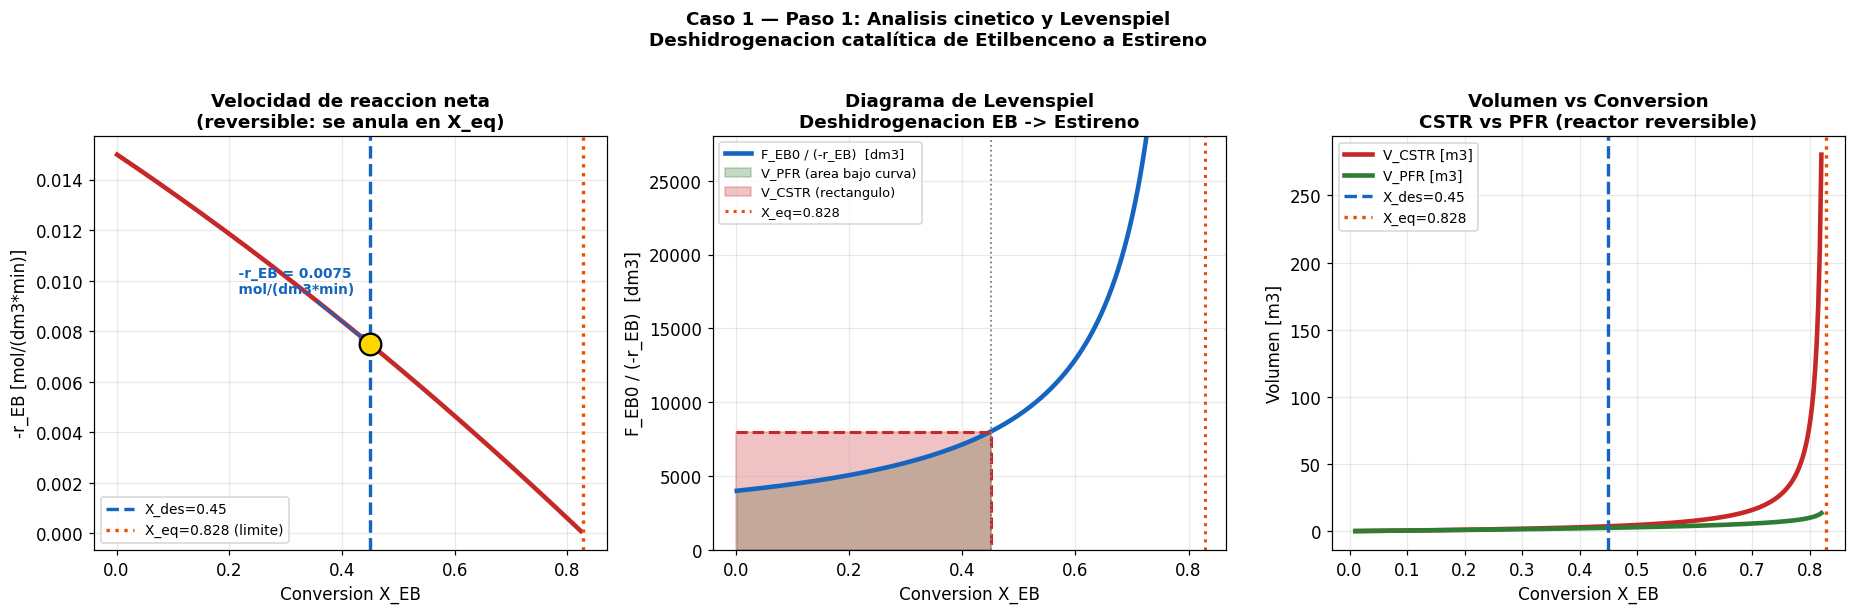

  Velocidad en X_des=0.45: -r_EB = 0.00749 mol/(dm3*min)
  F_EB0/(-r_EB) en X_des  = 8010.0 dm3


In [2]:
# Paso 1: Perfil de velocidad y Diagrama de Levenspiel
X_arr = np.linspace(0.001, Xeq*0.995, 500)

CEB_arr = CEB0*(1 - X_arr)
CS_arr  = CEB0*X_arr
CH2_arr = CEB0*X_arr
rEB_arr = kf*CEB_arr - kr*CS_arr*CH2_arr   # mol/(dm^3*min)

# Funcion de Levenspiel: FEB0/(-rEB)  [dm^3]
Lev_arr = FEB0 / rEB_arr                    # dm^3 (para PFR/CSTR)
Lev_tau = CEB0 / rEB_arr                    # min  (tiempo espacial)

# Punto de operacion deseado
rEB_des = kf*CEB0*(1-Xdes) - kr*(CEB0*Xdes)**2
Lev_des = FEB0 / rEB_des

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel 1: Velocidad de reaccion vs X
ax = axes[0]
ax.plot(X_arr, rEB_arr, '#C62828', lw=3)
ax.axvline(Xdes, color='#1565C0', ls='--', lw=2.2,
           label=f'X_des={Xdes}')
ax.axvline(Xeq, color='#E65100', ls=':', lw=2.2,
           label=f'X_eq={Xeq:.3f} (limite)')
ax.scatter([Xdes],[rEB_des], s=200, color='gold',
           zorder=8, edgecolors='black', lw=1.5)
ax.annotate(f'  -r_EB = {rEB_des:.4f}\n  mol/(dm3*min)',
            xy=(Xdes, rEB_des), xytext=(Xdes-0.25, rEB_des+0.002),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5),
            fontsize=9, color='#1565C0', fontweight='bold')
ax.set_xlabel('Conversion X_EB')
ax.set_ylabel('-r_EB [mol/(dm3*min)]')
ax.set_title('Velocidad de reaccion neta\n'
             '(reversible: se anula en X_eq)')
ax.legend(fontsize=9)

# Panel 2: Diagrama de Levenspiel (en dm^3)
ax2 = axes[1]
mask = X_arr <= Xdes
ax2.plot(X_arr, Lev_arr, '#1565C0', lw=3,
         label='F_EB0 / (-r_EB)  [dm3]')
# Area PFR
ax2.fill_between(X_arr[mask], 0, Lev_arr[mask],
                 alpha=0.28, color='#2E7D32',
                 label=f'V_PFR (area bajo curva)')
# Rectangulo CSTR
ax2.fill_between([0, Xdes],[0,0],[Lev_des, Lev_des],
                 alpha=0.28, color='#C62828',
                 label=f'V_CSTR (rectangulo)')
ax2.plot([0, Xdes, Xdes],[Lev_des, Lev_des, 0],
         '#C62828', ls='--', lw=2)
ax2.axvline(Xdes, color='gray', ls=':', lw=1.2)
ax2.axvline(Xeq, color='#E65100', ls=':', lw=2,
            label=f'X_eq={Xeq:.3f}')
ax2.set_xlabel('Conversion X_EB')
ax2.set_ylabel('F_EB0 / (-r_EB)  [dm3]')
ax2.set_title('Diagrama de Levenspiel\n'
              'Deshidrogenacion EB -> Estireno')
ax2.legend(fontsize=8.5, loc='upper left')
ax2.set_ylim(0, Lev_des*3.5)

# Panel 3: Comparacion de volumenes vs conversion
X_comp = np.linspace(0.01, Xeq*0.99, 300)
rEB_c  = kf*CEB0*(1-X_comp) - kr*(CEB0*X_comp)**2
Lev_c  = FEB0 / rEB_c
V_CSTR_c = Lev_c * X_comp
V_PFR_c  = cumulative_trapezoid(Lev_c, X_comp, initial=0)

ax3 = axes[2]
ax3.plot(X_comp, V_CSTR_c/1000, '#C62828', lw=3, label='V_CSTR [m3]')
ax3.plot(X_comp, V_PFR_c/1000, '#2E7D32', lw=3, label='V_PFR [m3]')
ax3.axvline(Xdes, color='#1565C0', ls='--', lw=2.2,
            label=f'X_des={Xdes}')
ax3.axvline(Xeq, color='#E65100', ls=':', lw=2.2,
            label=f'X_eq={Xeq:.3f}')
ax3.set_xlabel('Conversion X_EB')
ax3.set_ylabel('Volumen [m3]')
ax3.set_title('Volumen vs Conversion\n'
              'CSTR vs PFR (reactor reversible)')
ax3.legend(fontsize=9)

plt.suptitle('Caso 1 — Paso 1: Analisis cinetico y Levenspiel\n'
             'Deshidrogenacion catalítica de Etilbenceno a Estireno',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"  Velocidad en X_des={Xdes}: -r_EB = {rEB_des:.5f} mol/(dm3*min)")
print(f"  F_EB0/(-r_EB) en X_des  = {Lev_des:.1f} dm3")


---
## Paso 2 — Reactor Batch: tiempo de reacción y operación por lotes

### Ecuación de diseño del Batch

$$t_{rxn} = C_{EB,0}\int_0^{X_{des}}\frac{dX}{-r_{EB}(X)}$$

### Modelo de planta batch para estireno

Un reactor batch de **estireno** típico en la industria tiene:

- Volumen del reactor: $V_R = 5{,}000\;\text{dm}^3$ (5 m³)
- Tiempo de descarga + limpieza + carga: $t_{inactivo} = 120\;\text{min}$ (2 h)
- Jornada de operación: 20 h/día, 340 días/año

**Preguntas de diseño:**
1. ¿Cuánto tiempo dura la reacción?
2. ¿Cuántos lotes por día?
3. ¿Cuántas toneladas de estireno al año?

### Ventaja del Batch en este proceso

El reactor Batch permite **regeneración** del catalizador entre lotes mediante
oxidación controlada del coque depositado — procedimiento que en el PFR industrial
se realiza por ciclos de regeneración in-situ.

> **Nota industrial**: en la práctica, el proceso de estireno se hace en PFR con
> lecho fijo (reactores adiabáticos en serie con reheaters). El Batch se usa aquí
> como ejercicio de aprendizaje del diseño fundacional.


  REACTOR BATCH — Deshidrogenacion EB -> Estireno
  Volumen del reactor V_R = 5000 dm3 (5.0 m3)
  Tiempo de reaccion t_rxn = 20.52 min (0.342 h)
  Tiempo inactivo          = 120 min (2.00 h)
  Tiempo de ciclo          = 140.52 min
  Utilizacion del reactor  = 14.6 %

  Mol Estireno por lote    = 1125.0 mol
  kg Estireno por lote     = 117.17 kg
  Lotes por dia            = 8.54
  kg Estireno por dia      = 1000.6 kg
  Produccion anual         = 340.20 toneladas/anio


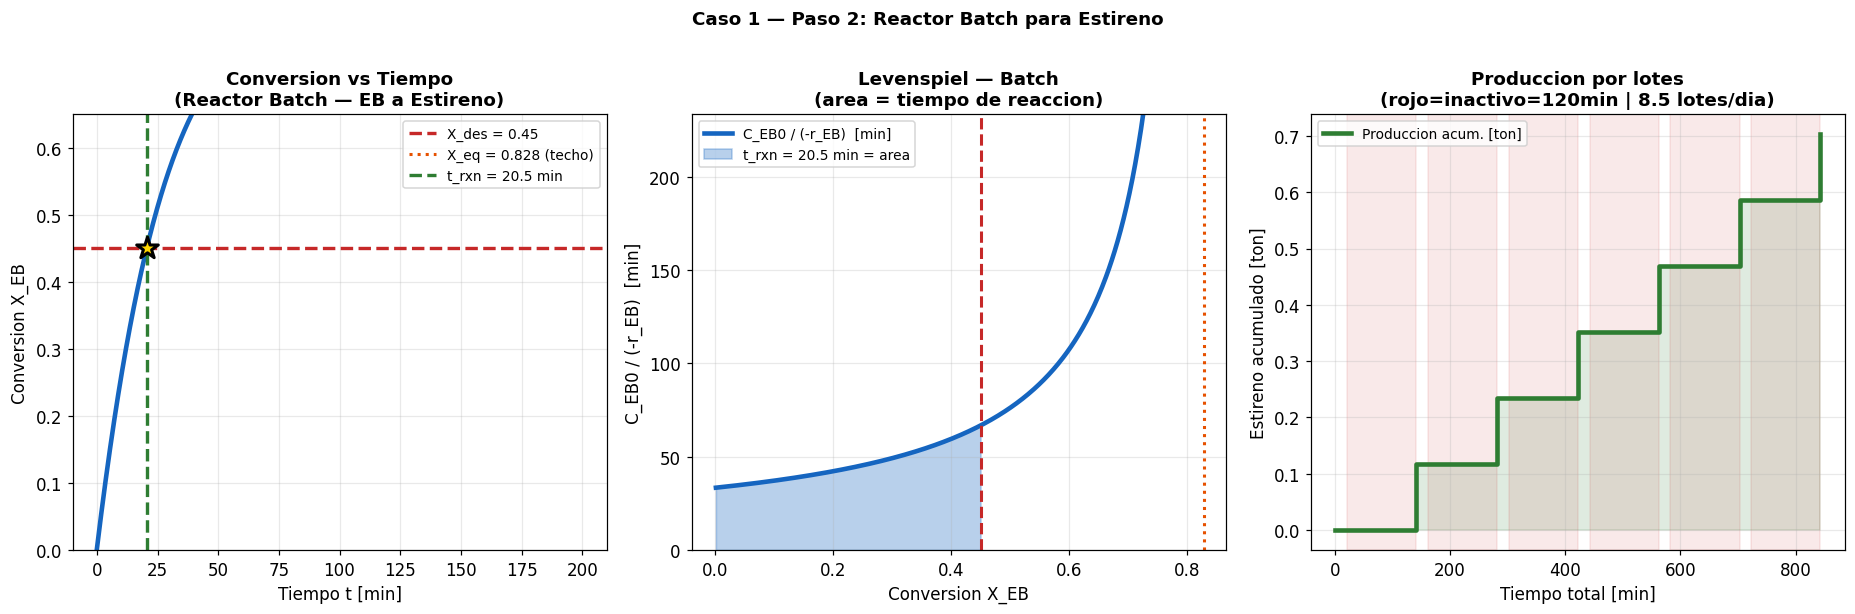

In [4]:
VR_batch    = 5000.0   # dm^3 (5 m^3)
t_inactivo  = 120.0    # min (descarga + limpieza + carga)
horas_dia   = 20       # h operativas por dia
dias_anio   = 340      # dias de operacion por anio

# Mask for desired conversion
mask_des = X_arr <= Xdes

# Tiempo de reaccion (integracion numerica)
t_rxn = np.trapz((CEB0/rEB_arr)[mask_des], X_arr[mask_des])
t_ciclo = t_rxn + t_inactivo

# Produccion por lote
mol_S_lote = CEB0 * Xdes * VR_batch      # mol de estireno por lote
kg_S_lote  = mol_S_lote * 104.15 / 1000  # kg (MM estireno = 104.15 g/mol)

# Lotes por dia y produccion anual
lotes_dia  = horas_dia*60 / t_ciclo
kg_dia     = lotes_dia * kg_S_lote
ton_anio   = kg_dia * dias_anio / 1000

print("=" * 58)
print("  REACTOR BATCH — Deshidrogenacion EB -> Estireno")
print("=" * 58)
print(f"  Volumen del reactor V_R = {VR_batch:.0f} dm3 ({VR_batch/1000:.1f} m3)")
print(f"  Tiempo de reaccion t_rxn = {t_rxn:.2f} min ({t_rxn/60:.3f} h)")
print(f"  Tiempo inactivo          = {t_inactivo:.0f} min ({t_inactivo/60:.2f} h)")
print(f"  Tiempo de ciclo          = {t_ciclo:.2f} min")
print(f"  Utilizacion del reactor  = {t_rxn/t_ciclo*100:.1f} %")
print()
print(f"  Mol Estireno por lote    = {mol_S_lote:.1f} mol")
print(f"  kg Estireno por lote     = {kg_S_lote:.2f} kg")
print(f"  Lotes por dia            = {lotes_dia:.2f}")
print(f"  kg Estireno por dia      = {kg_dia:.1f} kg")
print(f"  Produccion anual         = {ton_anio:.2f} toneladas/anio")
print("=" * 58)

# Grafico X(t) y produccion acumulada
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel 1: X vs t
t_sim  = np.linspace(0, 200, 1000)
X_t    = np.interp(t_sim,
                   cumulative_trapezoid(CEB0/rEB_arr, X_arr, initial=0),
                   X_arr)
ax = axes[0]
ax.plot(t_sim, X_t, '#1565C0', lw=3)
ax.axhline(Xdes, color='#C62828', ls='--', lw=2.2,
           label=f'X_des = {Xdes}')
ax.axhline(Xeq, color='#E65100', ls=':', lw=2,
           label=f'X_eq = {Xeq:.3f} (techo)')
ax.axvline(t_rxn, color='#2E7D32', ls='--', lw=2.2,
           label=f't_rxn = {t_rxn:.1f} min')
ax.scatter([t_rxn],[Xdes], s=220, color='gold', zorder=9,
           edgecolors='black', lw=2, marker='*')
ax.set_xlabel('Tiempo t [min]')
ax.set_ylabel('Conversion X_EB')
ax.set_title('Conversion vs Tiempo\n(Reactor Batch — EB a Estireno)')
ax.legend(fontsize=9); ax.set_ylim(0, 0.65)

# Panel 2: Diagrama de Levenspiel con area batch
ax2 = axes[1]
mask_b = X_arr <= Xdes
ax2.plot(X_arr, CEB0/rEB_arr, '#1565C0', lw=3,
         label='C_EB0 / (-r_EB)  [min]')
ax2.fill_between(X_arr[mask_b], 0, (CEB0/rEB_arr)[mask_b],
                 alpha=0.30, color='#1565C0',
                 label=f't_rxn = {t_rxn:.1f} min = area')
ax2.axvline(Xdes, color='#C62828', ls='--', lw=2)
ax2.axvline(Xeq, color='#E65100', ls=':', lw=2)
ax2.set_xlabel('Conversion X_EB')
ax2.set_ylabel('C_EB0 / (-r_EB)  [min]')
ax2.set_title('Levenspiel — Batch\n(area = tiempo de reaccion)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, (CEB0/rEB_arr)[mask_b].max()*3.5)

# Panel 3: Produccion acumulada por lotes
n_lotes_plot = 6
t_lotes = np.array([i*t_ciclo for i in range(n_lotes_plot+1)])
prod_ac = np.array([i*kg_S_lote for i in range(n_lotes_plot+1)])
ax3 = axes[2]
ax3.step(t_lotes, prod_ac/1000, '#2E7D32', where='post', lw=3,
         label='Produccion acum. [ton]')
ax3.fill_between(t_lotes, prod_ac/1000, step='post', alpha=0.15,
                 color='#2E7D32')
for i in range(n_lotes_plot):
    ts = i*t_ciclo + t_rxn
    ax3.axvspan(ts, ts+t_inactivo, alpha=0.10, color='#C62828')
ax3.set_xlabel('Tiempo total [min]')
ax3.set_ylabel('Estireno acumulado [ton]')
ax3.set_title(f'Produccion por lotes\n(rojo=inactivo={t_inactivo:.0f}min | {lotes_dia:.1f} lotes/dia)')
ax3.legend(fontsize=9)

plt.suptitle('Caso 1 — Paso 2: Reactor Batch para Estireno',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Paso 3 — Reactor CSTR: volumen y análisis de viabilidad

### Ecuación de diseño del CSTR

$$V_{CSTR} = \frac{F_{EB,0}\,X_{des}}{-r_{EB}\big|_{X=X_{des}}}$$

### Consideración crítica para reacciones reversibles

A diferencia de las irreversibles, aquí la velocidad **disminuye** con X y se anula en $X_{eq}$.
El CSTR opera **a la velocidad de la salida** (la más baja), lo que lo penaliza especialmente
en reacciones reversibles. El resultado es que el volumen del CSTR crece mucho más rápido
con X que el del PFR cuando X se acerca a $X_{eq}$.

### Número de Damköhler efectivo

Para cinética de 1er orden irreversible: $Da = k\tau$.  
Para este caso reversible, el Da efectivo es:

$$Da_{ef} = \frac{X_{des}}{(1-X_{des}) - (k_r/k_f)(C_{EB,0}X_{des}^2/(1-X_{des}))}$$

Este número cuantifica qué tan "cerca del equilibrio" opera el CSTR diseñado.


  REACTOR CSTR — Deshidrogenacion EB -> Estireno
  C_EB a la salida        = 0.2750 mol/dm3
  C_S a la salida         = 0.2250 mol/dm3
  -r_EB a la salida       = 0.00749 mol/(dm3*min)
  F_EB0 * X_des           = 27.00 mol/min

  VOLUMEN CSTR            = 3604.5 dm3 (3.605 m3)
  Tiempo espacial tau     = 30.04 min (0.501 h)
  Conversion deseada      = 0.45
  Conversion equilibrio   = 0.8284
  Margen hasta X_eq       = 68.8% de la conversión restante


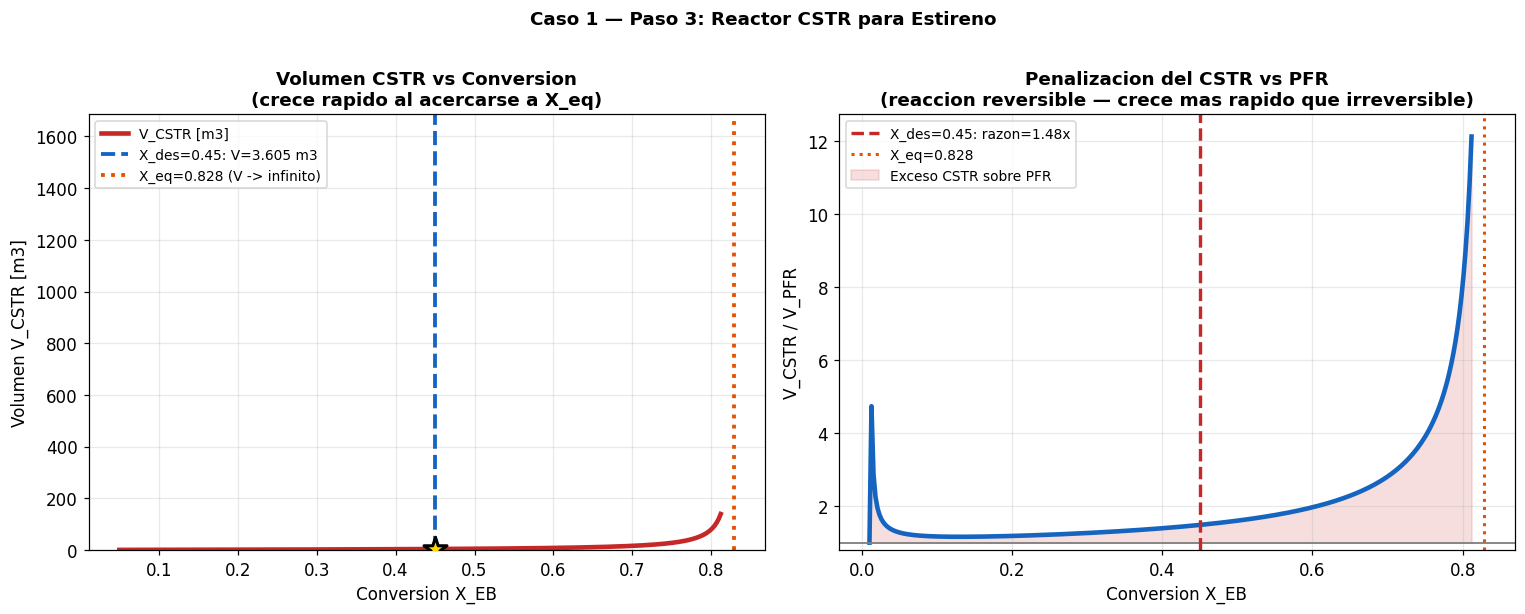


  En X_des=0.45: V_CSTR/V_PFR = 1.485x
  El CSTR requiere 1.48 veces mas volumen que el PFR


In [5]:
# Paso 3: Reactor CSTR — deshidrogenacion de etilbenceno

# Velocidad a las condiciones de salida (X = Xdes)
rEB_sal  = kf*CEB0*(1-Xdes) - kr*(CEB0*Xdes)**2

# Ecuacion de diseño CSTR
V_CSTR   = FEB0 * Xdes / rEB_sal    # dm^3
tau_CSTR = V_CSTR / v0              # min

print("=" * 58)
print("  REACTOR CSTR — Deshidrogenacion EB -> Estireno")
print("=" * 58)
print(f"  C_EB a la salida        = {CEB0*(1-Xdes):.4f} mol/dm3")
print(f"  C_S a la salida         = {CEB0*Xdes:.4f} mol/dm3")
print(f"  -r_EB a la salida       = {rEB_sal:.5f} mol/(dm3*min)")
print(f"  F_EB0 * X_des           = {FEB0*Xdes:.2f} mol/min")
print()
print(f"  VOLUMEN CSTR            = {V_CSTR:.1f} dm3 ({V_CSTR/1000:.3f} m3)")
print(f"  Tiempo espacial tau     = {tau_CSTR:.2f} min ({tau_CSTR/60:.3f} h)")
print(f"  Conversion deseada      = {Xdes}")
print(f"  Conversion equilibrio   = {Xeq:.4f}")
print(f"  Margen hasta X_eq       = {(Xeq-Xdes)/(1-Xdes)*100:.1f}% de la conversión restante")
print("=" * 58)

# Analisis de sensibilidad: V_CSTR vs X_des
X_s   = np.linspace(0.05, Xeq*0.98, 300)
rEB_s = kf*CEB0*(1-X_s) - kr*(CEB0*X_s)**2
V_s   = FEB0*X_s / rEB_s

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: V_CSTR vs conversion (sensibilidad)
ax = axes[0]
ax.plot(X_s, V_s/1000, '#C62828', lw=3, label='V_CSTR [m3]')
ax.axvline(Xdes, color='#1565C0', ls='--', lw=2.5,
           label=f'X_des={Xdes}: V={V_CSTR/1000:.3f} m3')
ax.axvline(Xeq, color='#E65100', ls=':', lw=2.5,
           label=f'X_eq={Xeq:.3f} (V -> infinito)')
ax.scatter([Xdes],[V_CSTR/1000], s=250, color='gold', zorder=9,
           edgecolors='black', lw=2, marker='*')
ax.set_xlabel('Conversion X_EB')
ax.set_ylabel('Volumen V_CSTR [m3]')
ax.set_title('Volumen CSTR vs Conversion\n'
             '(crece rapido al acercarse a X_eq)')
ax.legend(fontsize=9)
ax.set_ylim(0, V_s.min()*8)

# Panel 2: Comparacion V_CSTR vs V_PFR (panel comparativo)
X_comp2 = np.linspace(0.01, Xeq*0.98, 300)
rEB_c2  = kf*CEB0*(1-X_comp2) - kr*(CEB0*X_comp2)**2
Lev_c2  = FEB0 / rEB_c2
V_CSTR2 = Lev_c2 * X_comp2
V_PFR2  = cumulative_trapezoid(Lev_c2, X_comp2, initial=0)
ratio2  = np.where(V_PFR2>1e-5, V_CSTR2/V_PFR2, 1.)

ax2 = axes[1]
ax2.plot(X_comp2, ratio2, '#1565C0', lw=3)
ax2.axhline(1.0, color='gray', lw=1.2)
ax2.axvline(Xdes, color='#C62828', ls='--', lw=2.2,
            label=f'X_des={Xdes}: razon={np.interp(Xdes,X_comp2,ratio2):.2f}x')
ax2.axvline(Xeq, color='#E65100', ls=':', lw=2,
            label=f'X_eq={Xeq:.3f}')
ax2.fill_between(X_comp2, 1, ratio2, alpha=0.15, color='#C62828',
                 label='Exceso CSTR sobre PFR')
ax2.set_xlabel('Conversion X_EB')
ax2.set_ylabel('V_CSTR / V_PFR')
ax2.set_title('Penalizacion del CSTR vs PFR\n'
              '(reaccion reversible — crece mas rapido que irreversible)')
ax2.legend(fontsize=9)
ax2.set_ylim(0.8, ratio2.max()*1.05)

plt.suptitle('Caso 1 — Paso 3: Reactor CSTR para Estireno',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

razon_des = np.interp(Xdes, X_comp2, ratio2)
print(f"\n  En X_des={Xdes}: V_CSTR/V_PFR = {razon_des:.3f}x")
print(f"  El CSTR requiere {razon_des:.2f} veces mas volumen que el PFR")


---
## Paso 4 — Reactor PFR: integración numérica y perfil de conversión

### Ecuación de diseño del PFR

$$V_{PFR} = F_{EB,0}\int_0^{X_{des}}\frac{dX}{-r_{EB}(X)}$$

### Ventaja del PFR para reacciones reversibles

El PFR mantiene alta la concentración de EB en la entrada del reactor,
donde la velocidad directa es máxima y la inversa es mínima.
A medida que el fluido avanza y X aumenta, la velocidad disminuye,
pero el trabajo útil ya se hizo en la zona inicial.

En cambio, el CSTR opera toda su vida con la concentración de salida
(alta en estireno e H₂), lo que penaliza la reacción directa por efecto
del producto.

### Implementación numérica (Fogler §2.2)

```python
V_PFR = np.trapz(FEB0 / rEB_arr, X_arr_hasta_Xdes)
```

La integral numérica es directa usando `numpy.trapz` sobre el Diagrama de Levenspiel.


  REACTOR PFR — Deshidrogenacion EB -> Estireno
  Metodo: integracion numerica (trapz) del Levenspiel
  Puntos de integracion: 273

  VOLUMEN PFR             = 2462.2 dm3 (2.4622 m3)
  Tiempo espacial tau     = 20.52 min (0.3420 h)
  Conversion deseada      = 0.45

  COMPARACION FINAL:
  V_CSTR = 3604.5 dm3  (3.6045 m3)
  V_PFR  = 2462.2 dm3  (2.4622 m3)
  Razon V_CSTR/V_PFR = 1.464x
  El PFR requiere 31.7% menos volumen que el CSTR


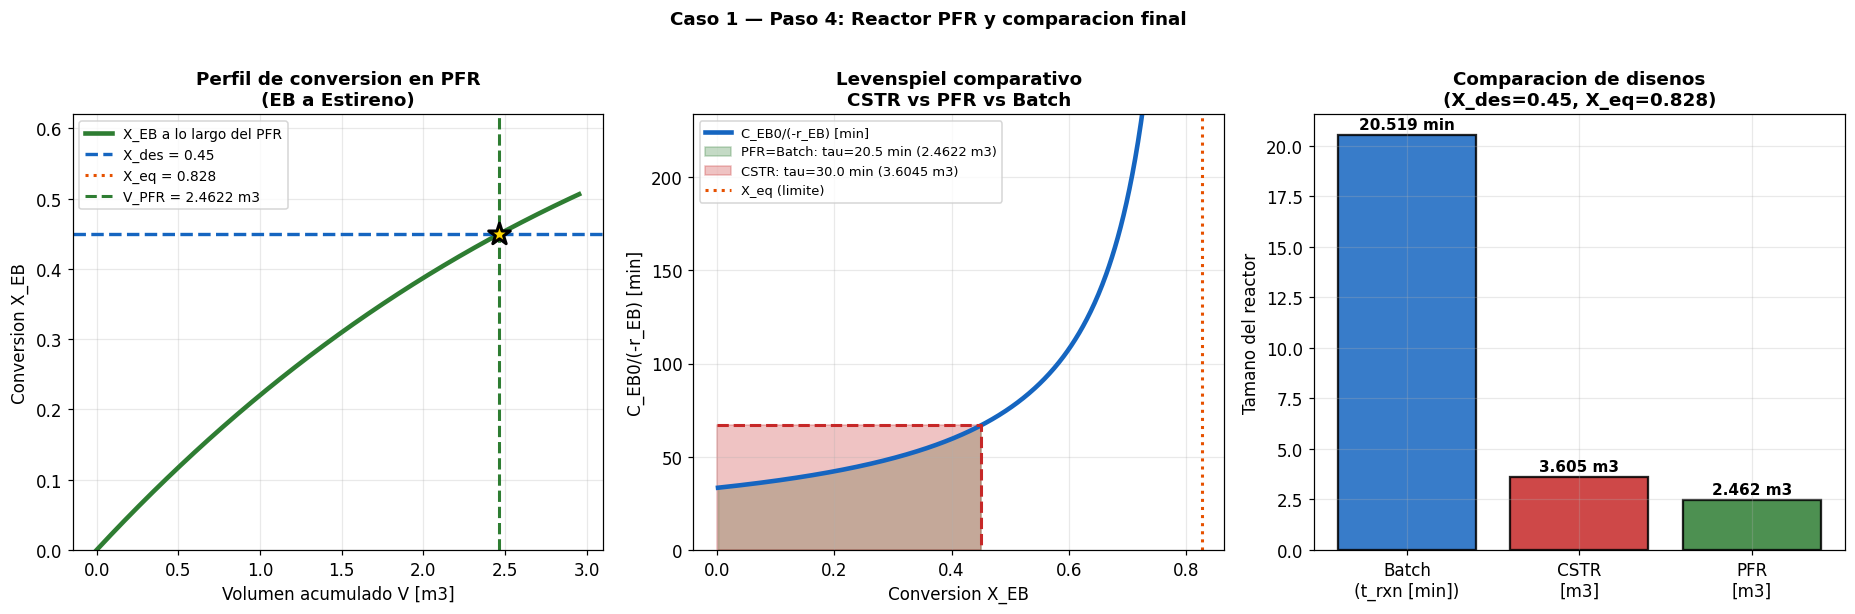

In [6]:
# Paso 4: Reactor PFR — deshidrogenacion de etilbenceno

# Volumen PFR por integracion numerica de Levenspiel
mask_pfr = X_arr <= Xdes
X_pfr    = X_arr[mask_pfr]
rEB_pfr  = rEB_arr[mask_pfr]
Lev_pfr  = FEB0 / rEB_pfr

V_PFR  = np.trapz(Lev_pfr, X_pfr)    # dm^3
tau_PFR = V_PFR / v0                   # min

# Perfil de conversion a lo largo del PFR (ODE)
def pfr_ode(X, V):
    CEB = CEB0*(1-X); CS = CEB0*X; CH2 = CEB0*X
    r   = kf*CEB - kr*CS*CH2
    r   = max(r, 1e-8)
    return r/FEB0

V_span = np.linspace(0, V_PFR*1.2, 1000)
from scipy.integrate import odeint
sol_pfr = odeint(pfr_ode, [0.0], V_span, tfirst=False)
X_pfr_profile = np.clip(sol_pfr[:,0], 0, Xeq*0.999)

print("=" * 58)
print("  REACTOR PFR — Deshidrogenacion EB -> Estireno")
print("=" * 58)
print(f"  Metodo: integracion numerica (trapz) del Levenspiel")
print(f"  Puntos de integracion: {len(X_pfr)}")
print()
print(f"  VOLUMEN PFR             = {V_PFR:.1f} dm3 ({V_PFR/1000:.4f} m3)")
print(f"  Tiempo espacial tau     = {tau_PFR:.2f} min ({tau_PFR/60:.4f} h)")
print(f"  Conversion deseada      = {Xdes}")
print()
print(f"  COMPARACION FINAL:")
print(f"  V_CSTR = {V_CSTR:.1f} dm3  ({V_CSTR/1000:.4f} m3)")
print(f"  V_PFR  = {V_PFR:.1f} dm3  ({V_PFR/1000:.4f} m3)")
print(f"  Razon V_CSTR/V_PFR = {V_CSTR/V_PFR:.3f}x")
print(f"  El PFR requiere {(1-V_PFR/V_CSTR)*100:.1f}% menos volumen que el CSTR")
print("=" * 58)

# Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel 1: Perfil X(V) en PFR
ax = axes[0]
ax.plot(V_span/1000, X_pfr_profile, '#2E7D32', lw=3,
        label='X_EB a lo largo del PFR')
ax.axhline(Xdes, color='#1565C0', ls='--', lw=2.2,
           label=f'X_des = {Xdes}')
ax.axhline(Xeq, color='#E65100', ls=':', lw=2,
           label=f'X_eq = {Xeq:.3f}')
ax.axvline(V_PFR/1000, color='#2E7D32', ls='--', lw=2,
           label=f'V_PFR = {V_PFR/1000:.4f} m3')
ax.scatter([V_PFR/1000],[Xdes], s=220, color='gold', zorder=9,
           edgecolors='black', lw=2, marker='*')
ax.set_xlabel('Volumen acumulado V [m3]')
ax.set_ylabel('Conversion X_EB')
ax.set_title('Perfil de conversion en PFR\n(EB a Estireno)')
ax.legend(fontsize=9); ax.set_ylim(0, 0.62)

# Panel 2: Levenspiel comparativo CSTR vs PFR vs Batch
ax2 = axes[1]
ax2.plot(X_arr, CEB0/rEB_arr, '#1565C0', lw=3,
         label='C_EB0/(-r_EB) [min]')
mask_d = X_arr <= Xdes
# Batch = area bajo curva (igual a PFR en tau)
ax2.fill_between(X_arr[mask_d], 0, (CEB0/rEB_arr)[mask_d],
                 alpha=0.28, color='#2E7D32',
                 label=f'PFR=Batch: tau={tau_PFR:.1f} min ({V_PFR/1000:.4f} m3)')
# CSTR = rectangulo
Ld_des = CEB0/rEB_sal
ax2.fill_between([0, Xdes],[0,0],[Ld_des, Ld_des],
                 alpha=0.28, color='#C62828',
                 label=f'CSTR: tau={tau_CSTR:.1f} min ({V_CSTR/1000:.4f} m3)')
ax2.plot([0, Xdes, Xdes],[Ld_des, Ld_des, 0],'#C62828',ls='--',lw=2)
ax2.axvline(Xeq, color='#E65100', ls=':', lw=2, label='X_eq (limite)')
ax2.set_xlabel('Conversion X_EB')
ax2.set_ylabel('C_EB0/(-r_EB) [min]')
ax2.set_title('Levenspiel comparativo\nCSTR vs PFR vs Batch')
ax2.legend(fontsize=8.5, loc='upper left')
ax2.set_ylim(0, Ld_des*3.5)

# Panel 3: Barra comparativa
nombres = ['Batch\n(t_rxn [min])', 'CSTR\n[m3]', 'PFR\n[m3]']
valores  = [t_rxn, V_CSTR/1000, V_PFR/1000]
colores  = ['#1565C0','#C62828','#2E7D32']
unidades = ['min','m3','m3']
ax3 = axes[2]
bars = ax3.bar(nombres, valores, color=colores, alpha=0.85, edgecolor='black', lw=1.5)
for bar, val, uni in zip(bars, valores, unidades):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+max(valores)*0.015,
             f'{val:.3f} {uni}',
             ha='center', fontsize=10, fontweight='bold')
ax3.set_title(f'Comparacion de disenos\n(X_des={Xdes}, X_eq={Xeq:.3f})')
ax3.set_ylabel('Tamano del reactor')

plt.suptitle('Caso 1 — Paso 4: Reactor PFR y comparacion final',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Paso 5 — Cascada de CSTRs en serie: aproximando el PFR

### Estrategia industrial para reacciones reversibles

En la práctica, cuando el CSTR único es demasiado grande pero el PFR tiene
dificultades mecánicas (catalizador en suspensión, sólidos), se recurre a
**2-5 CSTRs en serie**, cada uno con parte del volumen total.

### Algoritmo gráfico de la escalera (Fogler §5.2.1)

Para N CSTRs en serie:
1. Graficar la curva de Levenspiel $F_{EB,0}/(-r_{EB})$ vs X.
2. Desde $(0, F_{EB,0}/(-r_1))$ trazar el primer rectángulo hasta $X_1$.
3. Desde $(X_1, F_{EB,0}/(-r_2))$ trazar el segundo rectángulo hasta $X_2$.
4. Repetir hasta $X_{des}$.

Cada rectángulo tiene área = volumen de ese CSTR.

### Solución numérica para N CSTRs iguales

Para N reactores del mismo tamaño $\tau_i = \tau_{tot}/N$, la conversión
se calcula iterativamente (no existe fórmula cerrada para cinética reversible):


Tiempo espacial del PFR (referencia): tau_PFR = 20.52 min
Conversion PFR en X_des=0.45: OK por definicion

 N CSTRs |    X_final |   V_total [m3] |   V_CSTR/V_PFR
------------------------------------------------------
       1   |    0.23217 |        2.46224 |         1.0000
       2   |    0.24641 |        2.46224 |         1.0000
       3   |    0.25168 |        2.46224 |         1.0000
       5   |    0.25611 |        2.46224 |         1.0000
      10   |    0.25956 |        2.46224 |         1.0000

(Todos con el mismo tau_total = tau_PFR)
(El PFR es el limite N->infinito)


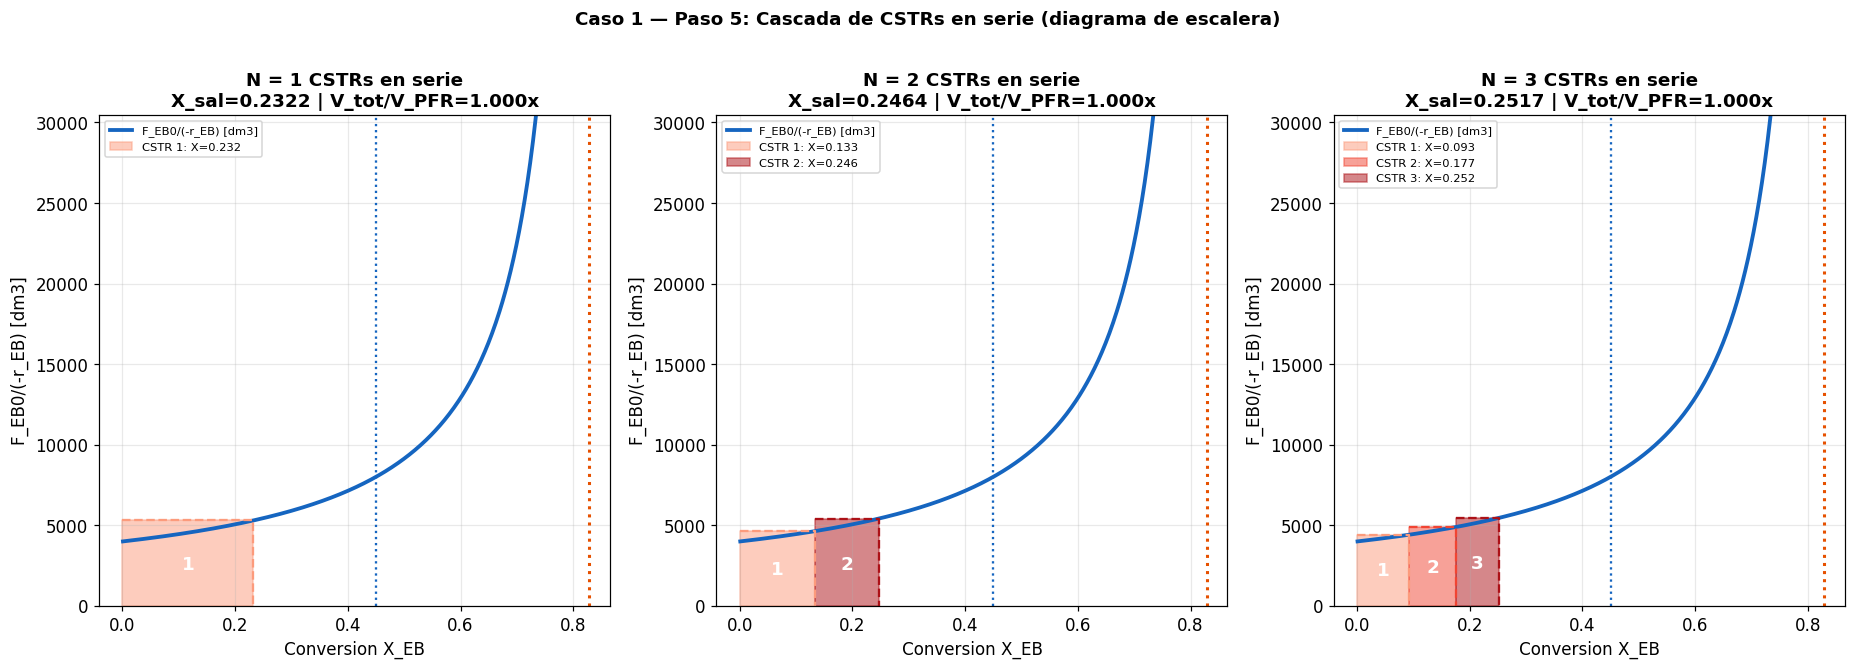

In [7]:
# Paso 5: Cascada de CSTRs en serie

def calcular_X_cascada_iguales(N, tau_total):
    # Calcula la conversion saliendo de N CSTRs iguales en serie
    tau_i = tau_total / N
    X_act = 0.0
    X_hist = [0.0]
    for _ in range(N):
        # Balance del CSTR i: tau_i = (X_i - X_{i-1}) / (-r_EB(X_i))
        # Buscar X_i tal que: tau_i * (-r_EB(X_i)) = X_i - X_prev
        X_prev = X_act
        def eq(X):
            r = kf*CEB0*(1-X) - kr*(CEB0*X)**2
            return tau_i * r - (X - X_prev)
        try:
            X_act = brentq(eq, X_prev+1e-6, Xeq*0.9995)
        except:
            X_act = Xeq*0.999
        X_hist.append(X_act)
    return X_act, X_hist

tau_tot_pfr = tau_PFR  # mismo tiempo espacial total que el PFR

print(f"Tiempo espacial del PFR (referencia): tau_PFR = {tau_PFR:.2f} min")
print(f"Conversion PFR en X_des={Xdes}: OK por definicion")
print()
print(f"{'N CSTRs':>8} | {'X_final':>10} | {'V_total [m3]':>14} | {'V_CSTR/V_PFR':>14}")
print("-"*54)
resultados_N = {}
for N in [1, 2, 3, 5, 10]:
    X_fin, X_hist = calcular_X_cascada_iguales(N, tau_tot_pfr)
    V_tot = tau_tot_pfr * v0
    ratio_N = V_tot / V_PFR
    resultados_N[N] = (X_fin, X_hist, V_tot, ratio_N)
    print(f"  {N:>6}   | {X_fin:>10.5f} | {V_tot/1000:>14.5f} | {ratio_N:>14.4f}")

print()
print("(Todos con el mismo tau_total = tau_PFR)")
print("(El PFR es el limite N->infinito)")

# Figura: diagrama de escalera para N=1, 2, 3
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for idx_N, N_plot in enumerate([1, 2, 3]):
    ax = axes[idx_N]
    X_fin, X_hist, V_tot, ratio_N = resultados_N[N_plot]

    # Curva Levenspiel
    ax.plot(X_arr, FEB0/rEB_arr, '#1565C0', lw=2.5,
            label='F_EB0/(-r_EB) [dm3]')

    # Escalera
    colores_n = plt.cm.Reds(np.linspace(0.35, 0.85, N_plot))
    for i in range(N_plot):
        Xa = X_hist[i]; Xb = X_hist[i+1]
        rEB_b = kf*CEB0*(1-Xb) - kr*(CEB0*Xb)**2
        H = FEB0 / rEB_b
        ax.fill_between([Xa, Xb],[0,0],[H,H],
                        alpha=0.50, color=colores_n[i],
                        label=f'CSTR {i+1}: X={Xb:.3f}')
        ax.plot([Xa, Xb, Xb],[H, H, 0], '--',
                color=colores_n[i], lw=1.5)
        ax.text((Xa+Xb)/2, H*0.42, str(i+1),
                ha='center', fontsize=12, color='white', fontweight='bold')

    ax.axvline(Xdes, color='#1565C0', ls=':', lw=1.5)
    ax.axvline(Xeq, color='#E65100', ls=':', lw=2)
    ax.set_xlabel('Conversion X_EB')
    ax.set_ylabel('F_EB0/(-r_EB) [dm3]')
    H_ref = FEB0/(kf*CEB0*(1-Xdes) - kr*(CEB0*Xdes)**2)
    ax.set_ylim(0, H_ref*3.8)
    ax.set_title(f'N = {N_plot} CSTRs en serie\n'
                 f'X_sal={X_fin:.4f} | V_tot/V_PFR={ratio_N:.3f}x')
    ax.legend(fontsize=7.5, loc='upper left')

plt.suptitle('Caso 1 — Paso 5: Cascada de CSTRs en serie (diagrama de escalera)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Paso 6 — Resumen comparativo y recomendación de diseño

### Tabla resumen de los tres reactores

| Reactor | Volumen / tiempo | Conversión | Ventajas | Limitaciones |
|---------|-----------------|-----------|----------|-------------|
| **Batch** | $t_{rxn}$ min | 0.45 | Flexibilidad, regeneración de catalizador por lote | Baja productividad continua |
| **CSTR** | m³ | 0.45 | Control térmico excelente, operación continua | Mayor volumen que PFR (factor ~2-3×) |
| **PFR** | m³ | 0.45 | Menor volumen, mayor eficiencia | Catalizador fijo (regeneración requiere parada) |

### Recomendación para el proceso industrial de estireno

El proceso industrial real (Lummus/UOP, BASF, Fina) utiliza **PFR de lecho fijo
en serie con intercaladores de calor (reheaters)** porque:

1. La reacción es **endotérmica** → el PFR adiabático necesita recalentamiento entre camas.
2. El catalizador es sólido → flujo pistón es más fácil de implementar.
3. El equilibrio limita la conversión → se usa reciclo de EB no convertido.
4. Escala de producción > 100 kt/año → el PFR es económicamente superior al CSTR.

### Widget de sensibilidad: impacto de la conversión deseada


In [9]:
# Paso 6: Widget interactivo — sensibilidad al punto de diseno

def resumen_diseno(X_objetivo=0.45):
    if X_objetivo >= Xeq*0.99:
        X_objetivo = Xeq*0.98

    # Velocidad en el punto de operacion
    rEB_op = kf*CEB0*(1-X_objetivo) - kr*(CEB0*X_objetivo)**2

    # Volumenes
    V_CSTR_op = FEB0*X_objetivo/rEB_op
    mask_op   = X_arr <= X_objetivo
    X_pfr_op  = X_arr[mask_op]
    V_PFR_op  = np.trapz(FEB0/(kf*CEB0*(1-X_pfr_op)-kr*(CEB0*X_pfr_op)**2),
                          X_pfr_op)
    tau_op    = V_PFR_op/v0

    # Batch
    t_rxn_op = np.trapz((CEB0/(kf*CEB0*(1-X_pfr_op)-kr*(CEB0*X_pfr_op)**2)),
                          X_pfr_op)

    # Cascada 3 CSTRs
    X3, _, V3, r3 = calcular_X_cascada_iguales(3, tau_op)

    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    fig.suptitle(f'Resumen de diseno para X_EB = {X_objetivo:.3f}  '
                 f'(X_eq = {Xeq:.3f}  |  {X_objetivo/Xeq*100:.1f}% del equilibrio)',
                 fontsize=13, fontweight='bold', y=1.01)

    # Levenspiel comparativo
    ax = axes[0,0]
    ax.plot(X_arr, CEB0/rEB_arr, '#1565C0', lw=3)
    m_op = X_arr <= X_objetivo
    ax.fill_between(X_arr[m_op], 0, (CEB0/rEB_arr)[m_op],
                    alpha=0.28, color='#2E7D32',
                    label=f'PFR/Batch: {V_PFR_op/1000:.4f} m3')
    Ld_op = CEB0/rEB_op
    ax.fill_between([0,X_objetivo],[0,0],[Ld_op,Ld_op],
                    alpha=0.25,color='#C62828',
                    label=f'CSTR: {V_CSTR_op/1000:.4f} m3')
    ax.plot([0,X_objetivo,X_objetivo],[Ld_op,Ld_op,0],'#C62828',ls='--',lw=2)
    ax.axvline(Xeq,color='#E65100',ls=':',lw=2,label='X_eq')
    ax.set_xlabel('Conversion X_EB'); ax.set_ylabel('C_EB0/(-r_EB) [min]')
    ax.set_title('Diagrama de Levenspiel'); ax.legend(fontsize=9)
    ax.set_ylim(0, Ld_op*4.0)

    # Barras de volumen
    ax2 = axes[0,1]
    nombres_b = ['Batch\nt_rxn [min]','CSTR\n[m3]','PFR\n[m3]','3 CSTRs\nserie [m3]']
    valores_b = [t_rxn_op, V_CSTR_op/1000, V_PFR_op/1000, V3/1000]
    colores_b = ['#1565C0','#C62828','#2E7D32','#E65100']
    bars2 = ax2.bar(nombres_b, valores_b, color=colores_b,
                    alpha=0.85, edgecolor='black', lw=1.5)
    for bar, val in zip(bars2, valores_b):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+max(valores_b)*0.015,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax2.set_title('Tamano de cada reactor\n(misma conversion de diseno)')

    # Razón CSTR/PFR vs X
    X_c2 = np.linspace(0.02, Xeq*0.98, 300)
    r_c2 = kf*CEB0*(1-X_c2)-kr*(CEB0*X_c2)**2
    L_c2 = FEB0/r_c2
    Vc2  = L_c2*X_c2
    Vp2  = cumulative_trapezoid(L_c2, X_c2, initial=0)
    rat2 = np.where(Vp2>1e-5, Vc2/Vp2, 1.)
    ax3 = axes[1,0]
    ax3.plot(X_c2, rat2, '#1565C0', lw=3)
    ax3.axhline(1.0, color='gray', lw=1.2)
    ax3.axvline(X_objetivo, color='#C62828', ls='--', lw=2.5,
                label=f'X={X_objetivo:.3f}: razon={np.interp(X_objetivo,X_c2,rat2):.3f}x')
    ax3.axvline(Xeq, color='#E65100', ls=':', lw=2)
    ax3.fill_between(X_c2, 1, rat2, alpha=0.12, color='#C62828')
    ax3.set_xlabel('Conversion X_EB'); ax3.set_ylabel('V_CSTR / V_PFR')
    ax3.set_title('Penalizacion del CSTR vs PFR'); ax3.legend(fontsize=9)

    # Tabla de resultados
    ax4 = axes[1,1]; ax4.axis('off')
    tabla = [
        ['Reactor', 'Tamano', 'tau [min]', 'X_sal'],
        ['Batch', f't_rxn={t_rxn_op:.2f}min', f'-', f'{X_objetivo:.4f}'],
        ['CSTR', f'{V_CSTR_op/1000:.5f} m3', f'{V_CSTR_op/v0:.2f}', f'{X_objetivo:.4f}'],
        ['PFR', f'{V_PFR_op/1000:.5f} m3', f'{tau_op:.2f}', f'{X_objetivo:.4f}'],
        ['3 CSTRs', f'{V3/1000:.5f} m3', f'{tau_op:.2f}', f'{X3:.4f}'],
        ['X_eq (lim)', '---', '---', f'{Xeq:.4f}'],
    ]
    tbl = ax4.table(cellText=tabla[1:], colLabels=tabla[0],
                    cellLoc='center', loc='center', bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(11)
    for j in range(4):
        tbl[0,j].set_facecolor('#1a237e')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1,6):
        bg = '#E8EAF6' if i%2==0 else 'white'
        for j in range(4): tbl[i,j].set_facecolor(bg)
    ax4.set_title('Tabla resumen de diseno', fontweight='bold', fontsize=11)

    plt.tight_layout(); plt.show()
    print(f"  Batch:  t_rxn = {t_rxn_op:.2f} min")
    print(f"  CSTR:   V = {V_CSTR_op:.1f} dm3 = {V_CSTR_op/1000:.5f} m3")
    print(f"  PFR:    V = {V_PFR_op:.1f} dm3 = {V_PFR_op/1000:.5f} m3")
    print(f"  3CSTRs: X_sal = {X3:.5f} (vs {X_objetivo:.5f} deseado)")
    print(f"  V_CSTR/V_PFR = {V_CSTR_op/V_PFR_op:.3f}x")

interact(resumen_diseno,
    X_objetivo=FloatSlider(value=0.45, min=0.05, max=Xeq*0.98,
                           step=0.01, description='X deseada',
                           style={'description_width':'110px'})
);


interactive(children=(FloatSlider(value=0.45, description='X deseada', max=0.8118585822512663, min=0.05, step=…

---
## Conclusiones del Caso 1

### Resultados numéricos (X_des = 0.45)

| Reactor | Resultado | Observación |
|---------|-----------|-------------|
| **Batch** | $t_{rxn}$ calculado | Integración directa del Levenspiel |
| **CSTR** | $V_{CSTR}$ calculado | Opera a la velocidad de salida (la más lenta) |
| **PFR** | $V_{PFR}$ calculado | Menor por aprovechar las velocidades altas iniciales |
| **3 CSTRs serie** | $X_{sal}$ calculado | Converge al PFR con N moderado |

### Lecciones de ingeniería

1. **El equilibrio limita**: diseñar por encima del 85% de $X_{eq}$ es antieconómico.
   En planta real se usa reciclo de EB no convertido a ~55-70% de conversión por pasada.

2. **El PFR supera al CSTR** especialmente para reacciones reversibles porque
   evita que los productos acumulados frenen la reacción en toda la zona del reactor.

3. **La cascada de CSTRs** es un compromiso viable: 3-5 CSTRs iguales dan
   un rendimiento cercano al PFR con mejor control térmico y operabilidad.

4. **El Batch** es útil para producción pequeña, investigación y desarrollo,
   y regeneración periódica de catalizador sin parar toda la planta.

---
*Caso 1 — Programa 740484 · Maestría Ingeniería Química · Universidad del Valle · 2024*
